<a href="https://colab.research.google.com/github/nishasn10/Aiml_project/blob/main/DBSCAN_un.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Loaded Successfully!
Rows: 62423
Columns: ['movieId', 'title', 'genres']

First 5 Rows:
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  

Features Used:
['(no genres listed)', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']

Cluster Results:
    movieId                                  t

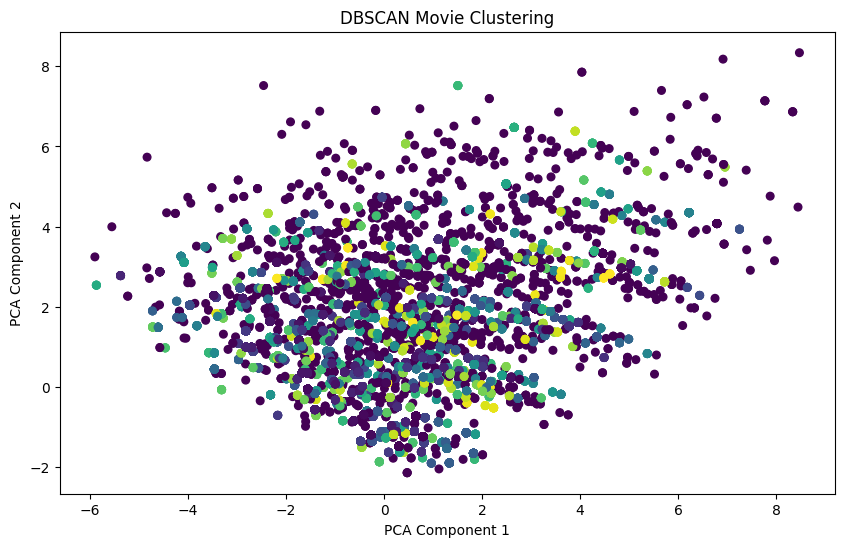

Streaming output truncated to the last 5000 lines.
         Sandlot, The (1993) Children|Comedy|Drama
     Secondhand Lions (2003) Children|Comedy|Drama
            Beethoven (1992) Children|Comedy|Drama
    Wondrous Oblivion (2003) Children|Comedy|Drama
Because of Winn-Dixie (2005) Children|Comedy|Drama
         Ice Princess (2005) Children|Comedy|Drama
       Material Girls (2006) Children|Comedy|Drama

-----------------------------
Cluster: 191
-----------------------------
                                         title                  genres
                         That Darn Cat! (1965) Children|Comedy|Mystery
                          That Darn Cat (1997) Children|Comedy|Mystery
                    Eloise at the Plaza (2003) Children|Comedy|Mystery
                             Get a Clue (2002) Children|Comedy|Mystery
Roxy Hunter and the Myth of the Mermaid (2008) Children|Comedy|Mystery

-----------------------------
Cluster: 192
-----------------------------
                  

In [8]:
# ============================================
# DBSCAN - MOVIE CLUSTERING
# Unsupervised Machine Learning
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# ============================================
# 1. LOAD DATASET
# ============================================

df = pd.read_csv("movies.csv")

print("Dataset Loaded Successfully!")
print("Rows:", len(df))
print("Columns:", df.columns.tolist())

# ============================================
# 2. DISPLAY DATA
# ============================================

print("\nFirst 5 Rows:")
print(df.head())

# ============================================
# 3. HANDLE MISSING VALUES
# ============================================

df["genres"] = df["genres"].fillna("Unknown")

# ============================================
# 4. CREATE GENRE FEATURES
# ============================================

# Get all unique genres

all_genres = set()

for genres in df["genres"]:
    for genre in genres.split("|"):
        all_genres.add(genre)

all_genres = sorted(all_genres)

# Create binary columns

for genre in all_genres:

    df[genre] = df["genres"].apply(
        lambda x: 1 if genre in x.split("|") else 0
    )

# ============================================
# 5. SELECT FEATURES
# ============================================

X = df[all_genres]

print("\nFeatures Used:")
print(all_genres)

# ============================================
# 6. STANDARDIZATION
# ============================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ============================================
# 7. APPLY DBSCAN
# ============================================

dbscan = DBSCAN(
    eps=1.2,
    min_samples=4
)

df["Cluster"] = dbscan.fit_predict(X_scaled)

# ============================================
# 8. DISPLAY CLUSTER RESULTS
# ============================================

print("\nCluster Results:")

print(
    df[
        ["movieId", "title", "genres", "Cluster"]
    ].head(20)
)

# ============================================
# 9. CLUSTER COUNTS
# ============================================

print("\nNumber of Movies in Each Cluster:")

print(
    df["Cluster"]
    .value_counts()
    .sort_index()
)

# ============================================
# 10. NUMBER OF CLUSTERS
# ============================================

cluster_labels = set(df["Cluster"])

if -1 in cluster_labels:
    cluster_labels.remove(-1)

number_of_clusters = len(cluster_labels)

print(
    "\nTotal Clusters:",
    number_of_clusters
)

# ============================================
# 11. NOISE COUNT
# ============================================

noise_count = (
    df["Cluster"] == -1
).sum()

print(
    "Noise Movies:",
    noise_count
)

# ============================================
# 12. PCA
# ============================================

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

df["PCA1"] = X_pca[:, 0]
df["PCA2"] = X_pca[:, 1]

# ============================================
# 13. VISUALIZATION
# ============================================

plt.figure(figsize=(10, 6))

plt.scatter(
    df["PCA1"],
    df["PCA2"],
    c=df["Cluster"],
    s=30
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.title(
    "DBSCAN Movie Clustering"
)

plt.show()

# ============================================
# 14. SILHOUETTE SCORE
# ============================================

valid_data = df["Cluster"] != -1

if (
    number_of_clusters >= 2
    and valid_data.sum() > number_of_clusters
):

    score = silhouette_score(
        X_scaled[valid_data],
        df.loc[valid_data, "Cluster"]
    )

    print(
        "\nSilhouette Score:",
        round(score, 4)
    )

else:

    print(
        "\nSilhouette Score cannot be calculated."
    )

# ============================================
# 15. SHOW CLUSTER-WISE MOVIES
# ============================================

print("\nCluster-wise Movie Examples:")

for cluster in sorted(
    df["Cluster"].unique()
):

    print("\n-----------------------------")
    print("Cluster:", cluster)
    print("-----------------------------")

    movies = df[
        df["Cluster"] == cluster
    ][
        ["title", "genres"]
    ].head(10)

    print(
        movies.to_string(index=False)
    )

# ============================================
# 16. FINAL RESULT
# ============================================

print("\n================================")
print("DBSCAN COMPLETED")
print("================================")

print("Total Movies:", len(df))
print("Total Clusters:", number_of_clusters)
print("Noise Movies:", noise_count)